In [8]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import snntorch as snn
import snntorch.spikegen as spikegen


df = pd.read_csv("final_data.csv")



In [9]:
df['Flow_delta'] = df['Flow_L_min'].diff()

In [10]:
df['Flow_delta'] = df['Flow_delta'].fillna(0)

In [11]:
df['Flow_low'] = (df['Flow_L_min'] < 0.2).astype(int)

In [12]:
df['Flow_ratio'] = df['Flow_L_min'] / (df['Turbidity_smooth'] + 1)

In [13]:
df.head(50)

,Flow_L_min,label,TDS_smooth,Turbidity_smooth,Flow_delta,Flow_low,Flow_ratio
0,0.27,2,825.6,2532.2,0.00,0,0.000107
1,0.53,1,1229.0,3100.2,0.26,0,0.000171
2,0.27,2,899.0,3121.0,-0.26,0,0.000086
3,0.27,2,816.6,2424.0,0.00,0,0.000111
4,1.33,0,934.2,1662.2,1.06,0,0.000800
5,1.20,0,902.2,1695.4,-0.13,0,0.000707
6,0.27,3,889.0,1713.0,-0.93,0,0.000158
7,1.47,0,1010.8,1677.4,1.20,0,0.000876
8,0.67,3,986.2,2540.0,-0.80,0,0.000264
9,0.13,2,1284.4,2548.0,-0.54,1,0.000051


In [14]:
df['label'].value_counts()

label
1    1095
0     972
2     863
3     615
Name: count, dtype: int64

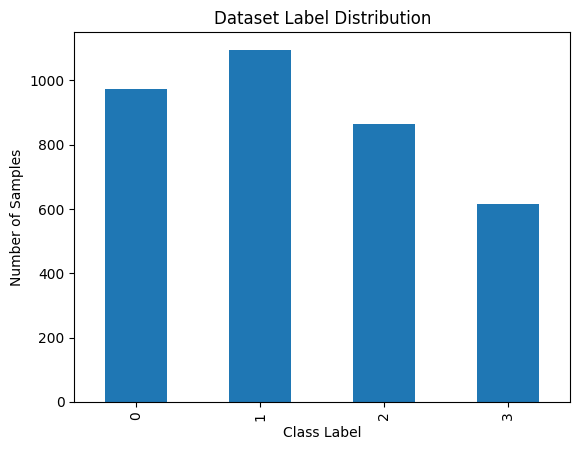

In [15]:
import matplotlib.pyplot as plt

df['label'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.title("Dataset Label Distribution")
plt.show()

In [24]:

X = df[['TDS_smooth','Turbidity_smooth','Flow_L_min','Flow_delta','Flow_low',"Flow_ratio"]]
y = df['label']



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)


scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values)
y_test = torch.tensor(y_test.values)


train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)



num_inputs = 6
num_hidden = 20
num_outputs = 4
num_steps = 40




class Net(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=0.9)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=0.9)

    def forward(self, x):

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []

        for step in range(x.size(0)):

            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk2_rec.append(spk2)

        return torch.stack(spk2_rec)



model = Net()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)



train_loss_list = []
train_acc_list = []
val_acc_list = []

epochs = 50

for epoch in range(epochs):

    total_loss = 0
    correct = 0
    total = 0

    for data, targets in train_loader:

        spikes = spikegen.rate(data, num_steps=num_steps)

        optimizer.zero_grad()

        spk_out = model(spikes)

        # KEEP ORIGINAL (no change in results)
        loss = loss_fn(spk_out.sum(0), targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # train accuracy
        _, pred = spk_out.sum(0).max(1)
        correct += (pred == targets).sum().item()
        total += targets.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # validation accuracy
    with torch.no_grad():
        test_spikes = spikegen.rate(X_test, num_steps=num_steps)
        test_spk = model(test_spikes)
        _, test_pred = test_spk.sum(0).max(1)
        val_acc = (test_pred == y_test).float().mean().item()

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 0 | Loss: 1.1526 | Train Acc: 0.6181 | Val Acc: 0.7433
Epoch 1 | Loss: 0.5251 | Train Acc: 0.7814 | Val Acc: 0.7800
Epoch 2 | Loss: 0.4932 | Train Acc: 0.7810 | Val Acc: 0.8195
Epoch 3 | Loss: 0.4465 | Train Acc: 0.8025 | Val Acc: 0.8279
Epoch 4 | Loss: 0.4535 | Train Acc: 0.7976 | Val Acc: 0.7969
Epoch 5 | Loss: 0.4268 | Train Acc: 0.8159 | Val Acc: 0.8519
Epoch 6 | Loss: 0.3956 | Train Acc: 0.8163 | Val Acc: 0.8223
Epoch 7 | Loss: 0.4041 | Train Acc: 0.8269 | Val Acc: 0.8124
Epoch 8 | Loss: 0.3779 | Train Acc: 0.8237 | Val Acc: 0.8138
Epoch 9 | Loss: 0.3897 | Train Acc: 0.8290 | Val Acc: 0.8463
Epoch 10 | Loss: 0.4039 | Train Acc: 0.8212 | Val Acc: 0.8618
Epoch 11 | Loss: 0.3827 | Train Acc: 0.8311 | Val Acc: 0.8350
Epoch 12 | Loss: 0.3706 | Train Acc: 0.8392 | Val Acc: 0.8491
Epoch 13 | Loss: 0.3723 | Train Acc: 0.8357 | Val Acc: 0.8392
Epoch 14 | Loss: 0.3702 | Train Acc: 0.8290 | Val Acc: 0.8463
Epoch 15 | Loss: 0.3549 | Train Acc: 0.8413 | Val Acc: 0.8449
Epoch 16 | Loss: 0

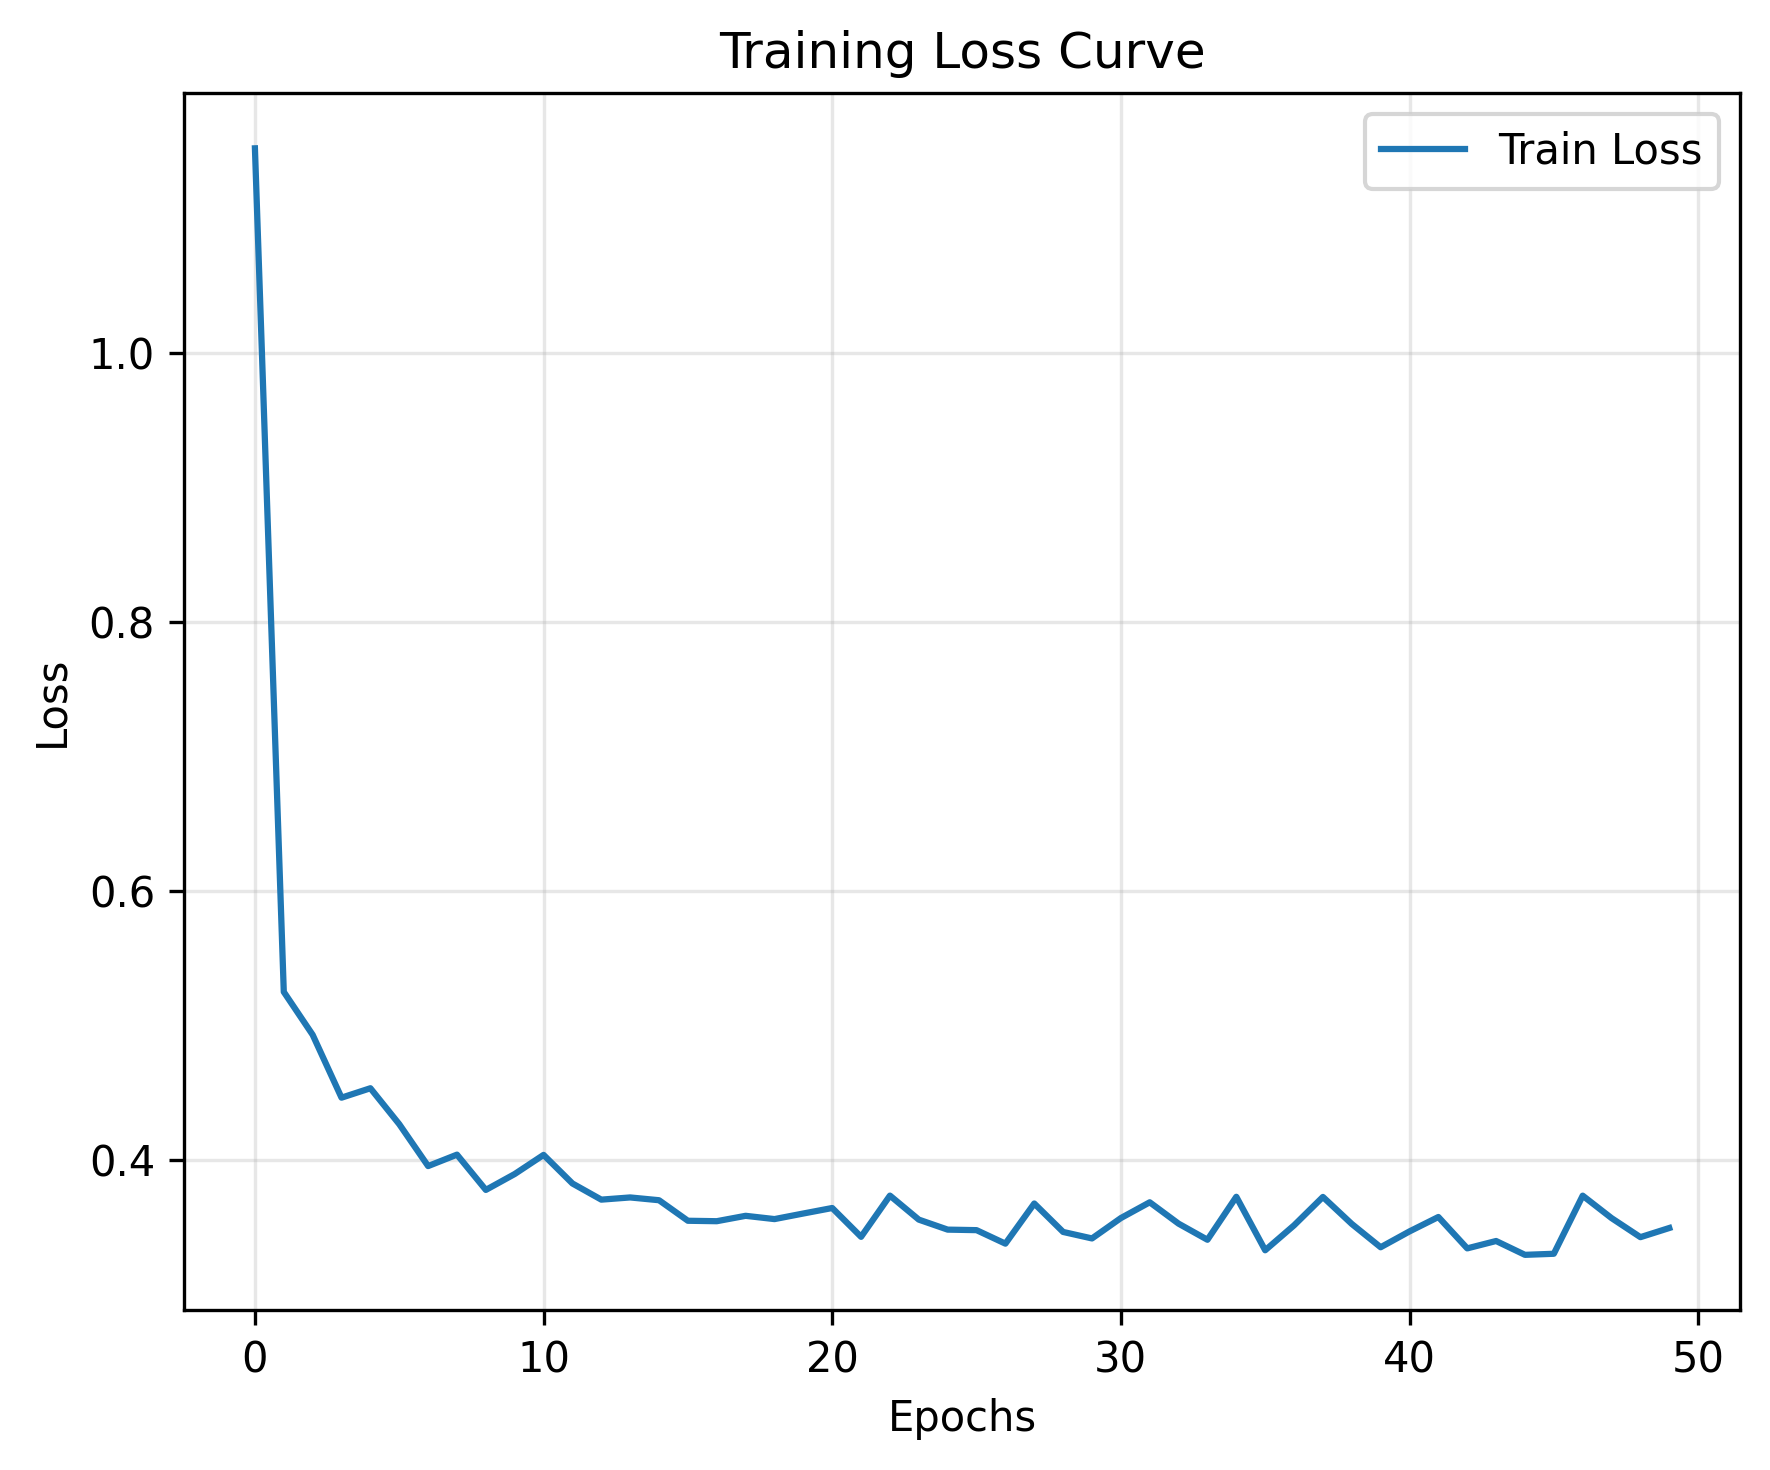

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5), dpi=300)
plt.plot(train_loss_list, label="Train Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

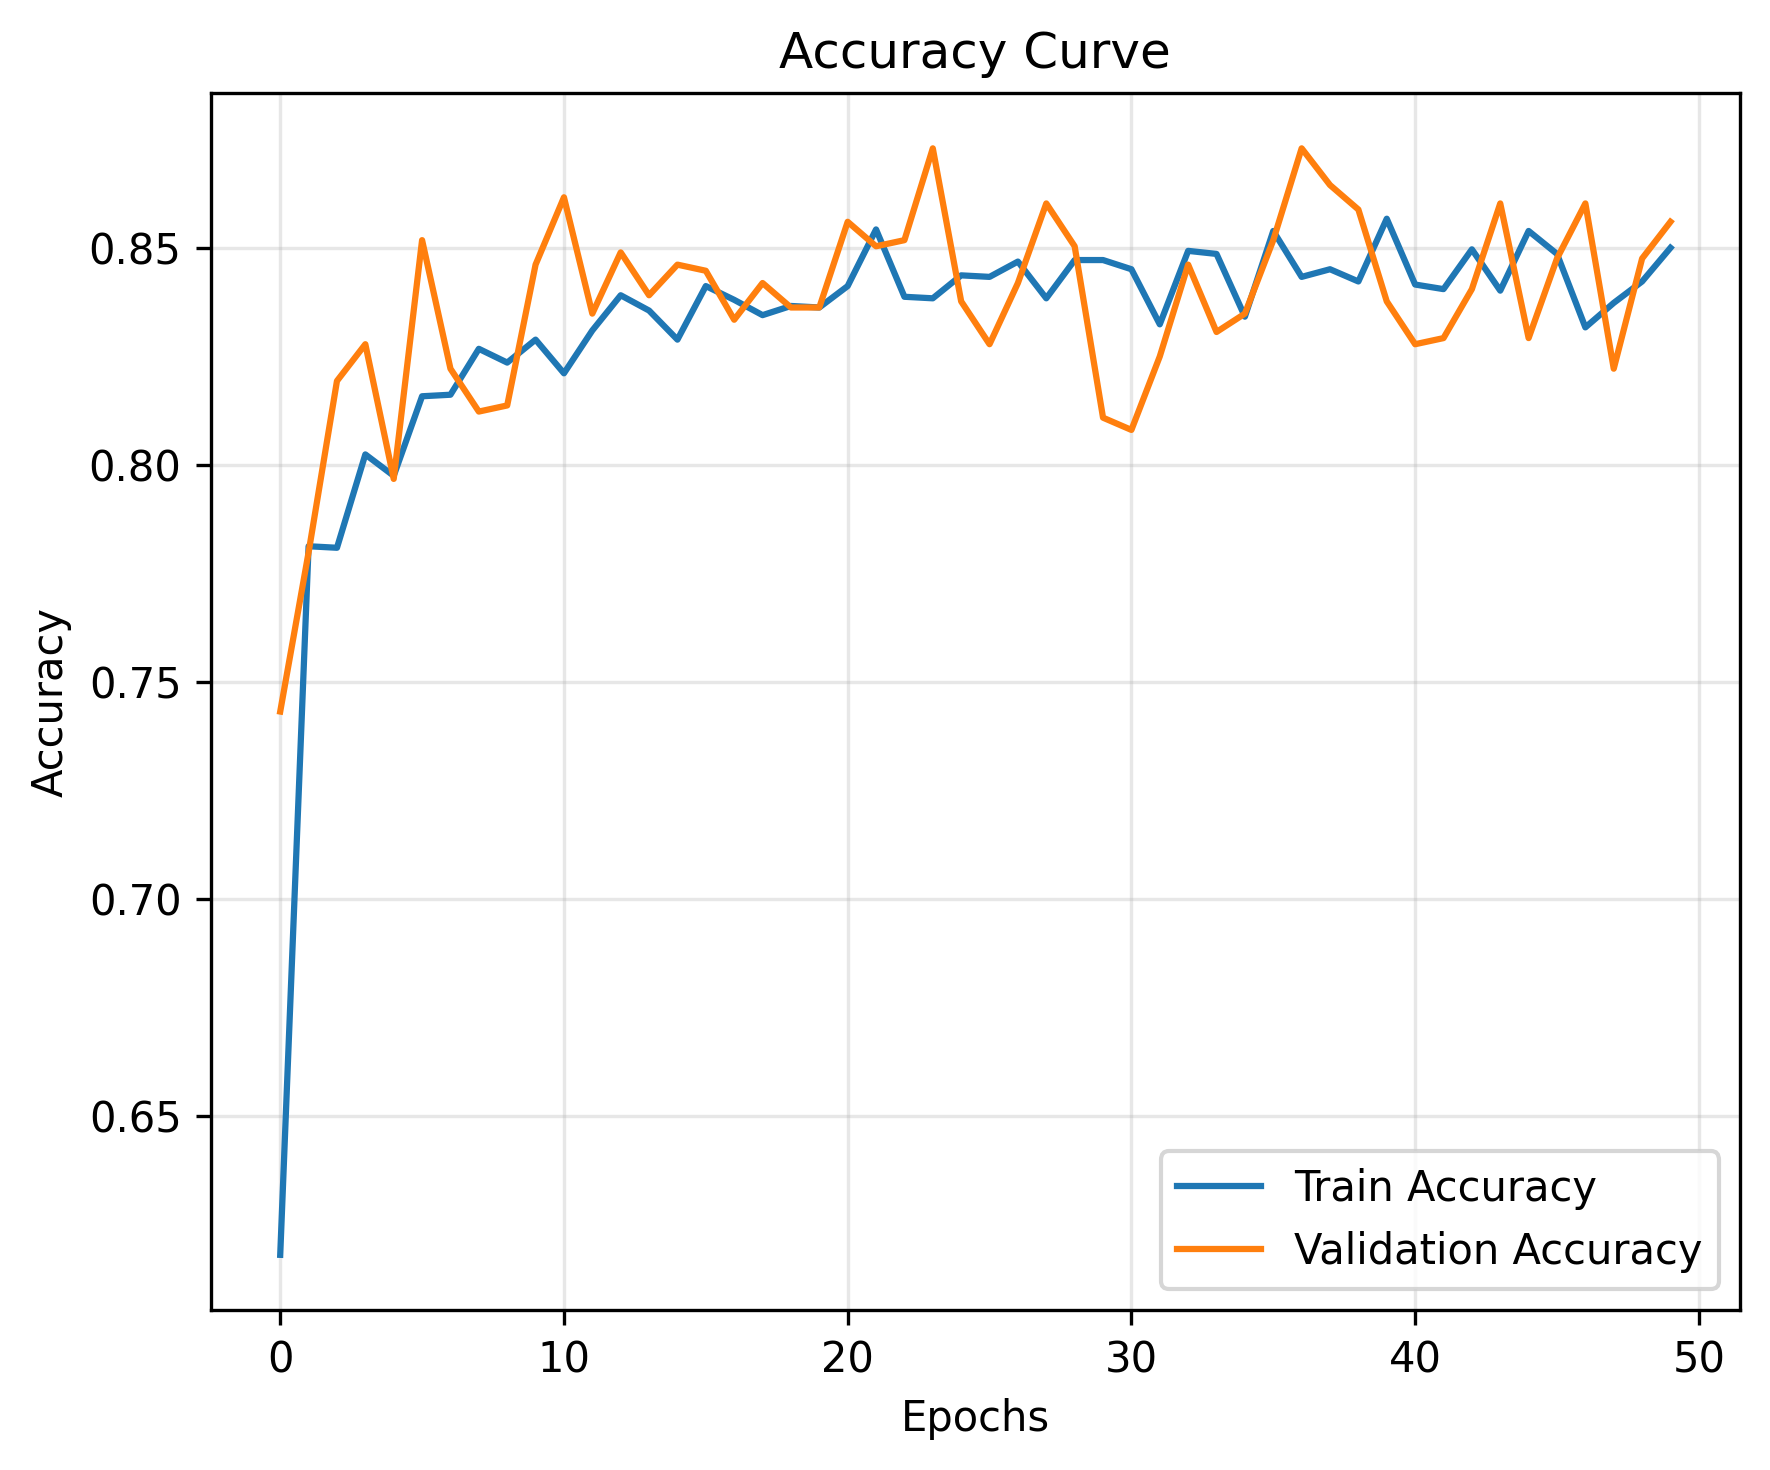

In [27]:
plt.figure(figsize=(6,5), dpi=300)

plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

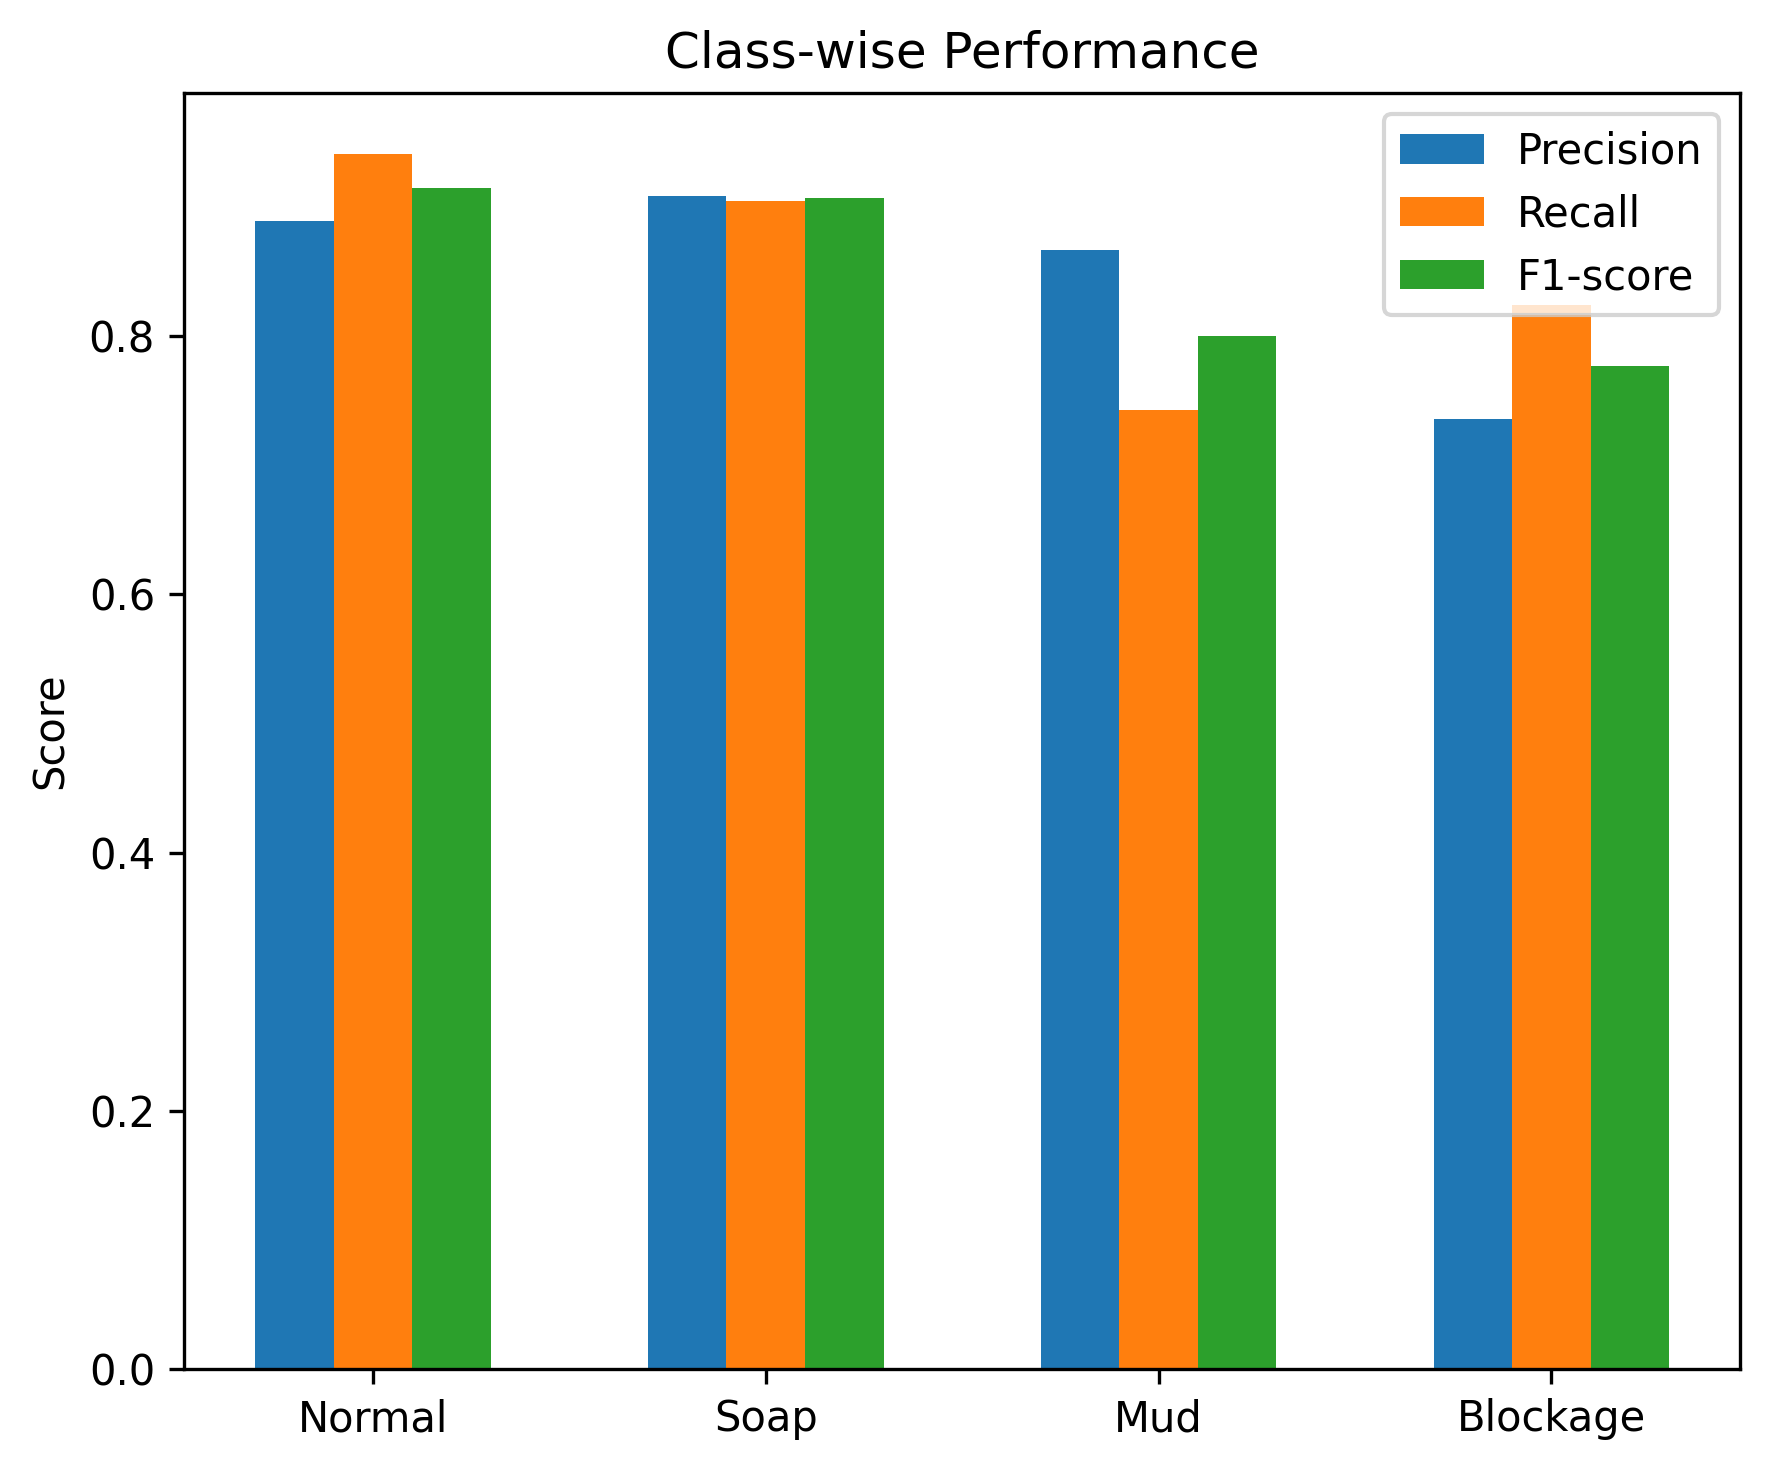

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

with torch.no_grad():
    test_spikes = spikegen.rate(X_test, num_steps=num_steps)
    test_spk = model(test_spikes)
    _, predicted = test_spk.sum(0).max(1)

precision = precision_score(y_test, predicted, average=None)
recall = recall_score(y_test, predicted, average=None)
f1 = f1_score(y_test, predicted, average=None)

labels = ["Normal", "Soap", "Mud", "Blockage"]
x = np.arange(len(labels))

plt.figure(figsize=(6,5), dpi=300)

plt.bar(x-0.2, precision, width=0.2, label="Precision")
plt.bar(x, recall, width=0.2, label="Recall")
plt.bar(x+0.2, f1, width=0.2, label="F1-score")

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Class-wise Performance")

plt.legend()
plt.tight_layout()
plt.show()

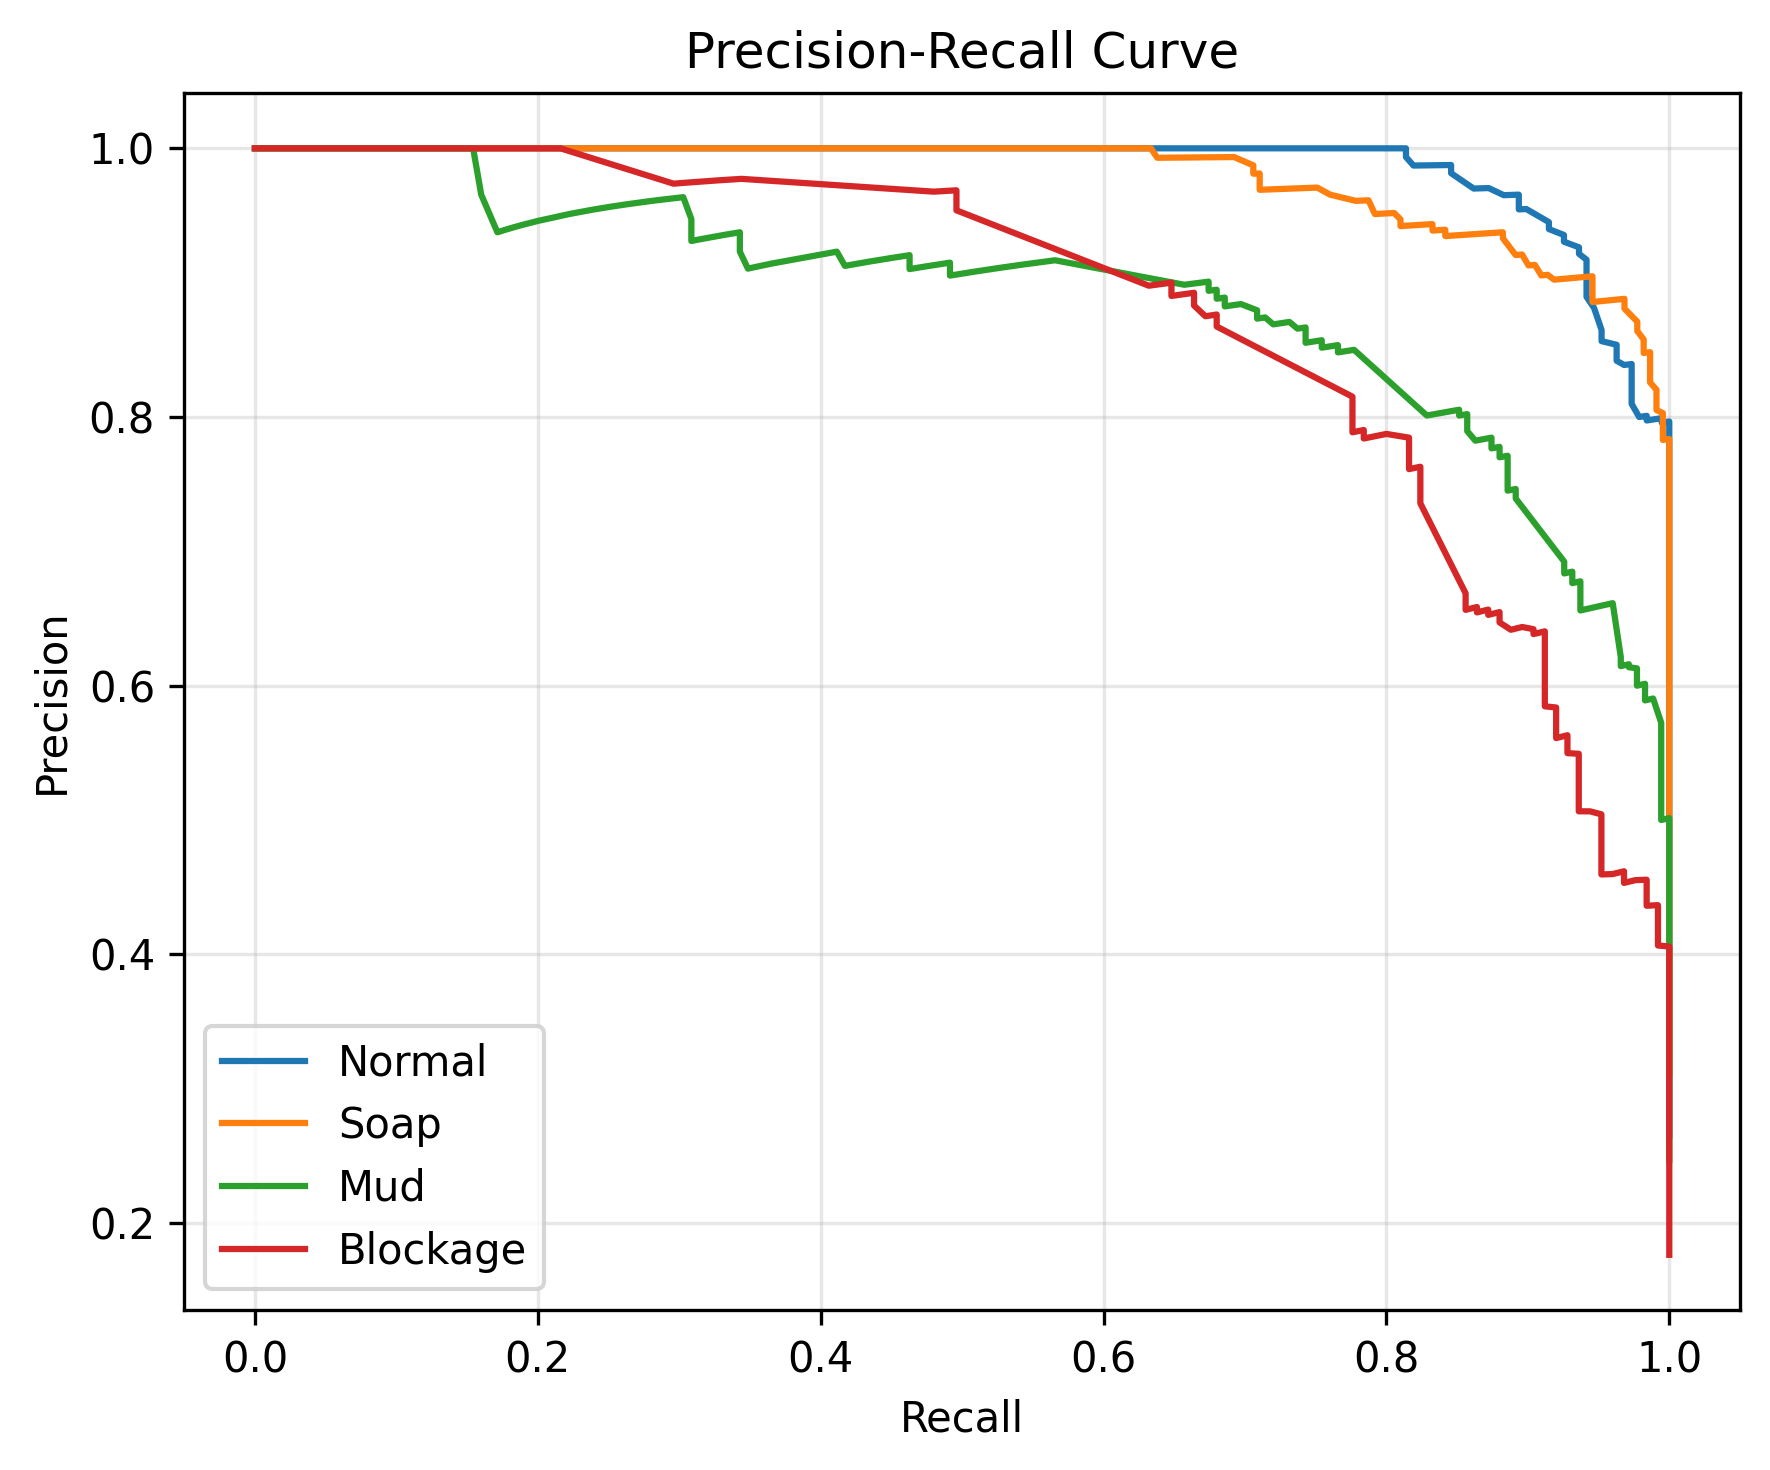

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_test.cpu().numpy(), classes=[0,1,2,3])

# softmax only for evaluation (NO effect on results)
scores = torch.softmax(test_spk.sum(0), dim=1).detach().cpu().numpy()

plt.figure(figsize=(6,5), dpi=300)

for i in range(4):
    p, r, _ = precision_recall_curve(y_bin[:, i], scores[:, i])
    plt.plot(r, p, label=f"{labels[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

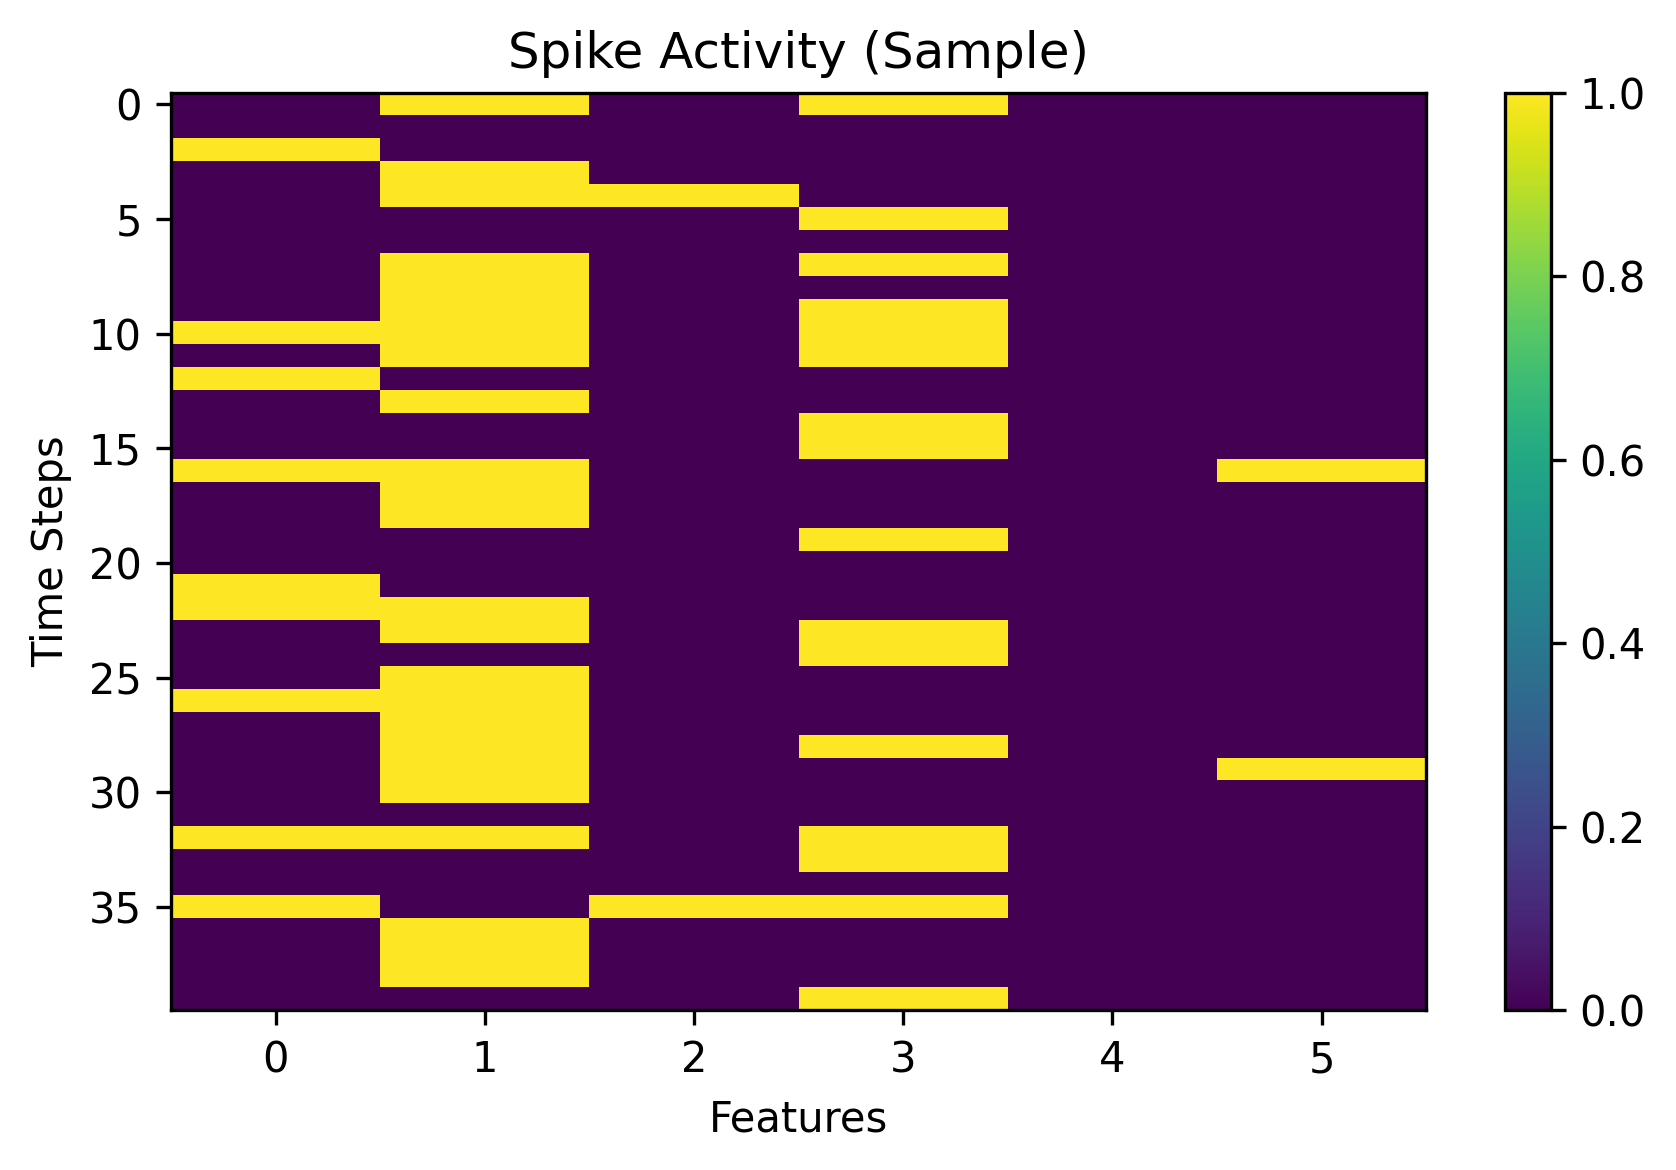

In [30]:
plt.figure(figsize=(6,4), dpi=300)

sample_spikes = test_spikes[:, 0, :].cpu()

plt.imshow(sample_spikes, aspect='auto')

plt.xlabel("Features")
plt.ylabel("Time Steps")
plt.title("Spike Activity (Sample)")

plt.colorbar()
plt.tight_layout()
plt.show()

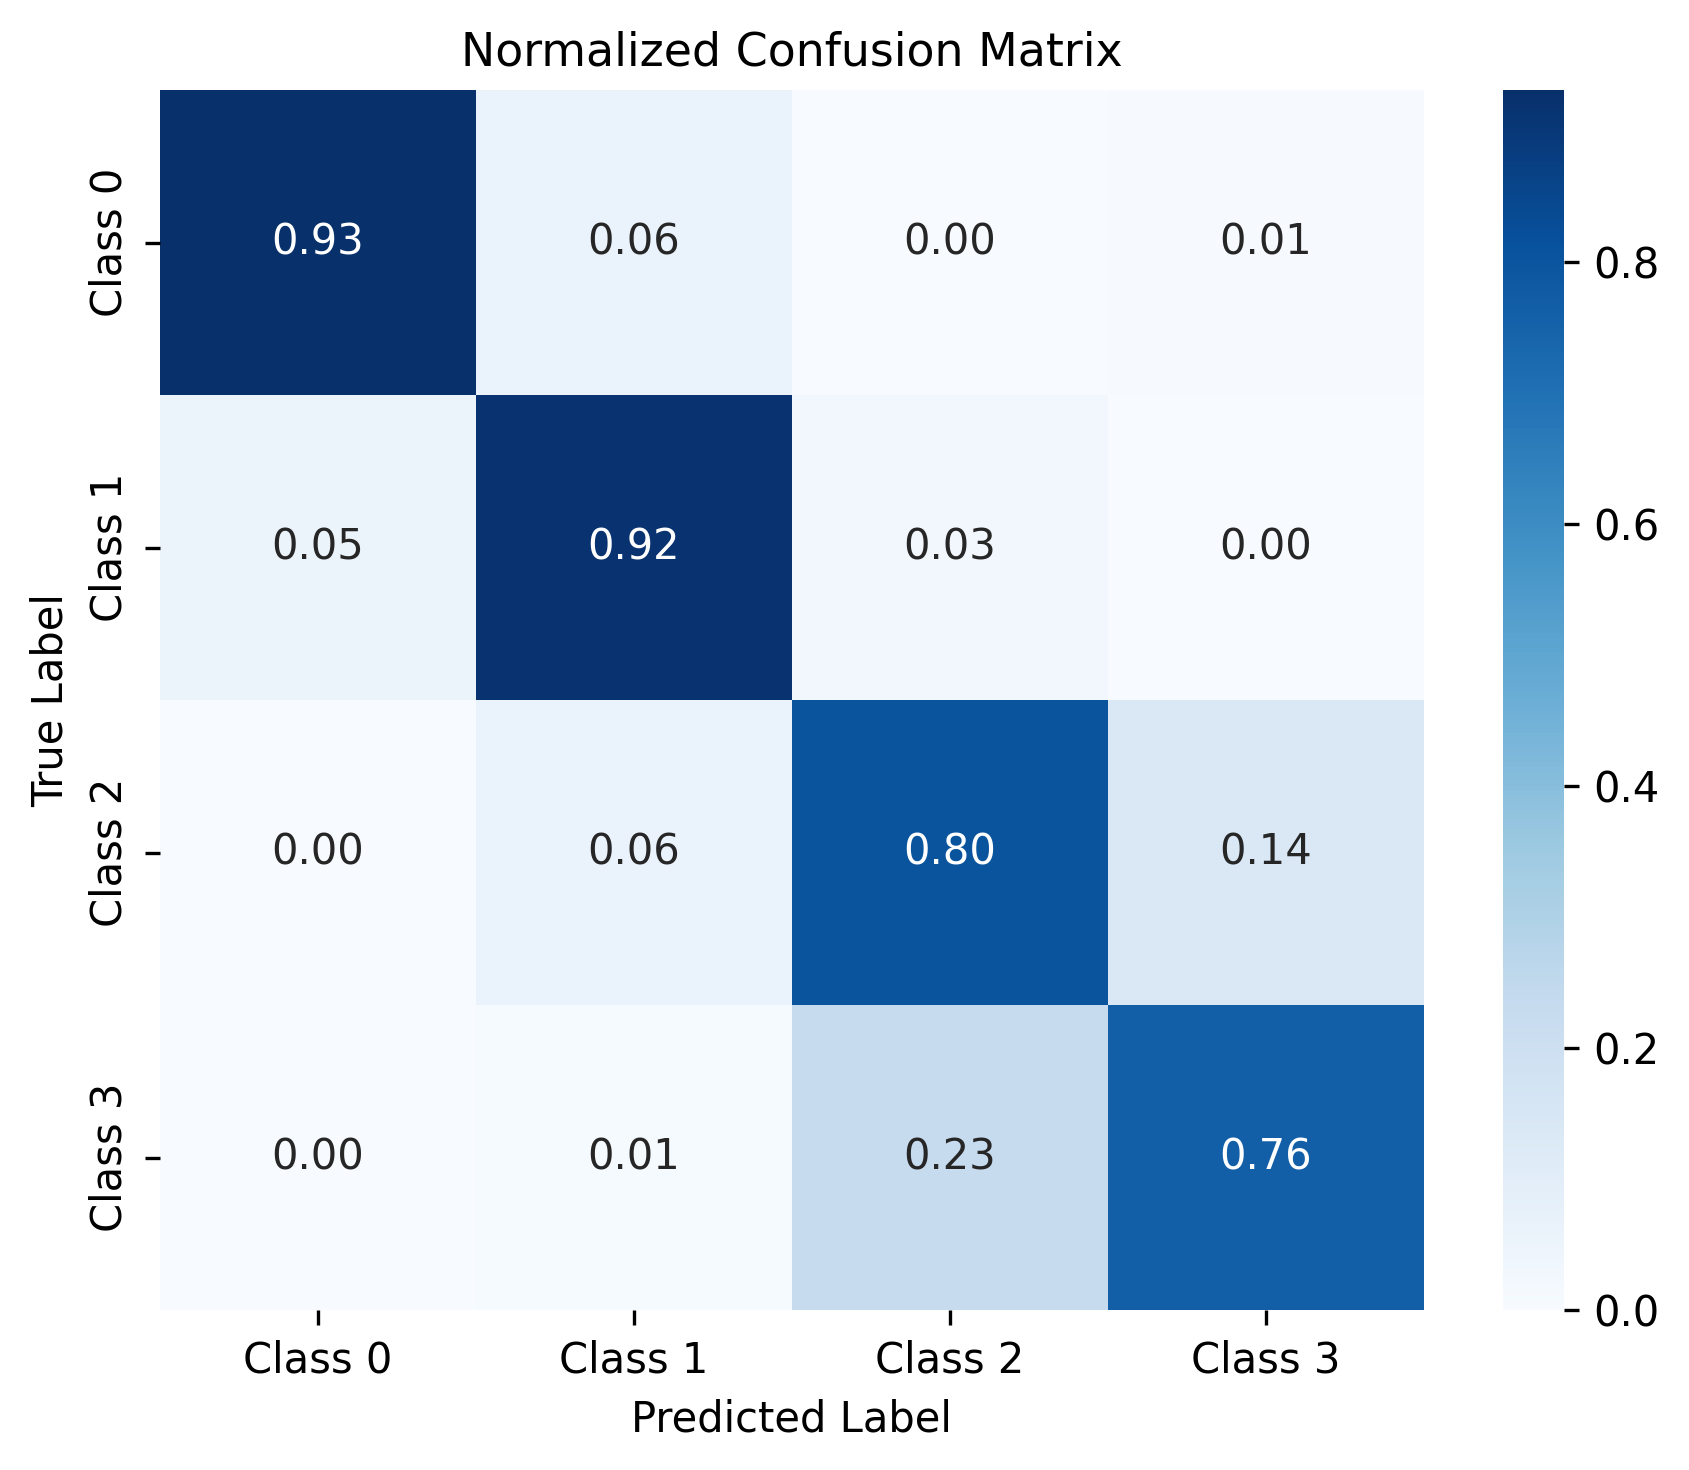

In [25]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicted)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = ["Class 0", "Class 1", "Class 2", "Class 3"]

plt.figure(figsize=(6,5), dpi=300)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels,
            cbar=True)

plt.xlabel("Predicted Label", fontsize=10)
plt.ylabel("True Label", fontsize=10)
plt.title("Normalized Confusion Matrix", fontsize=11)

plt.tight_layout()
plt.savefig("confusion_matrix_ieee.png", dpi=300)
plt.show()

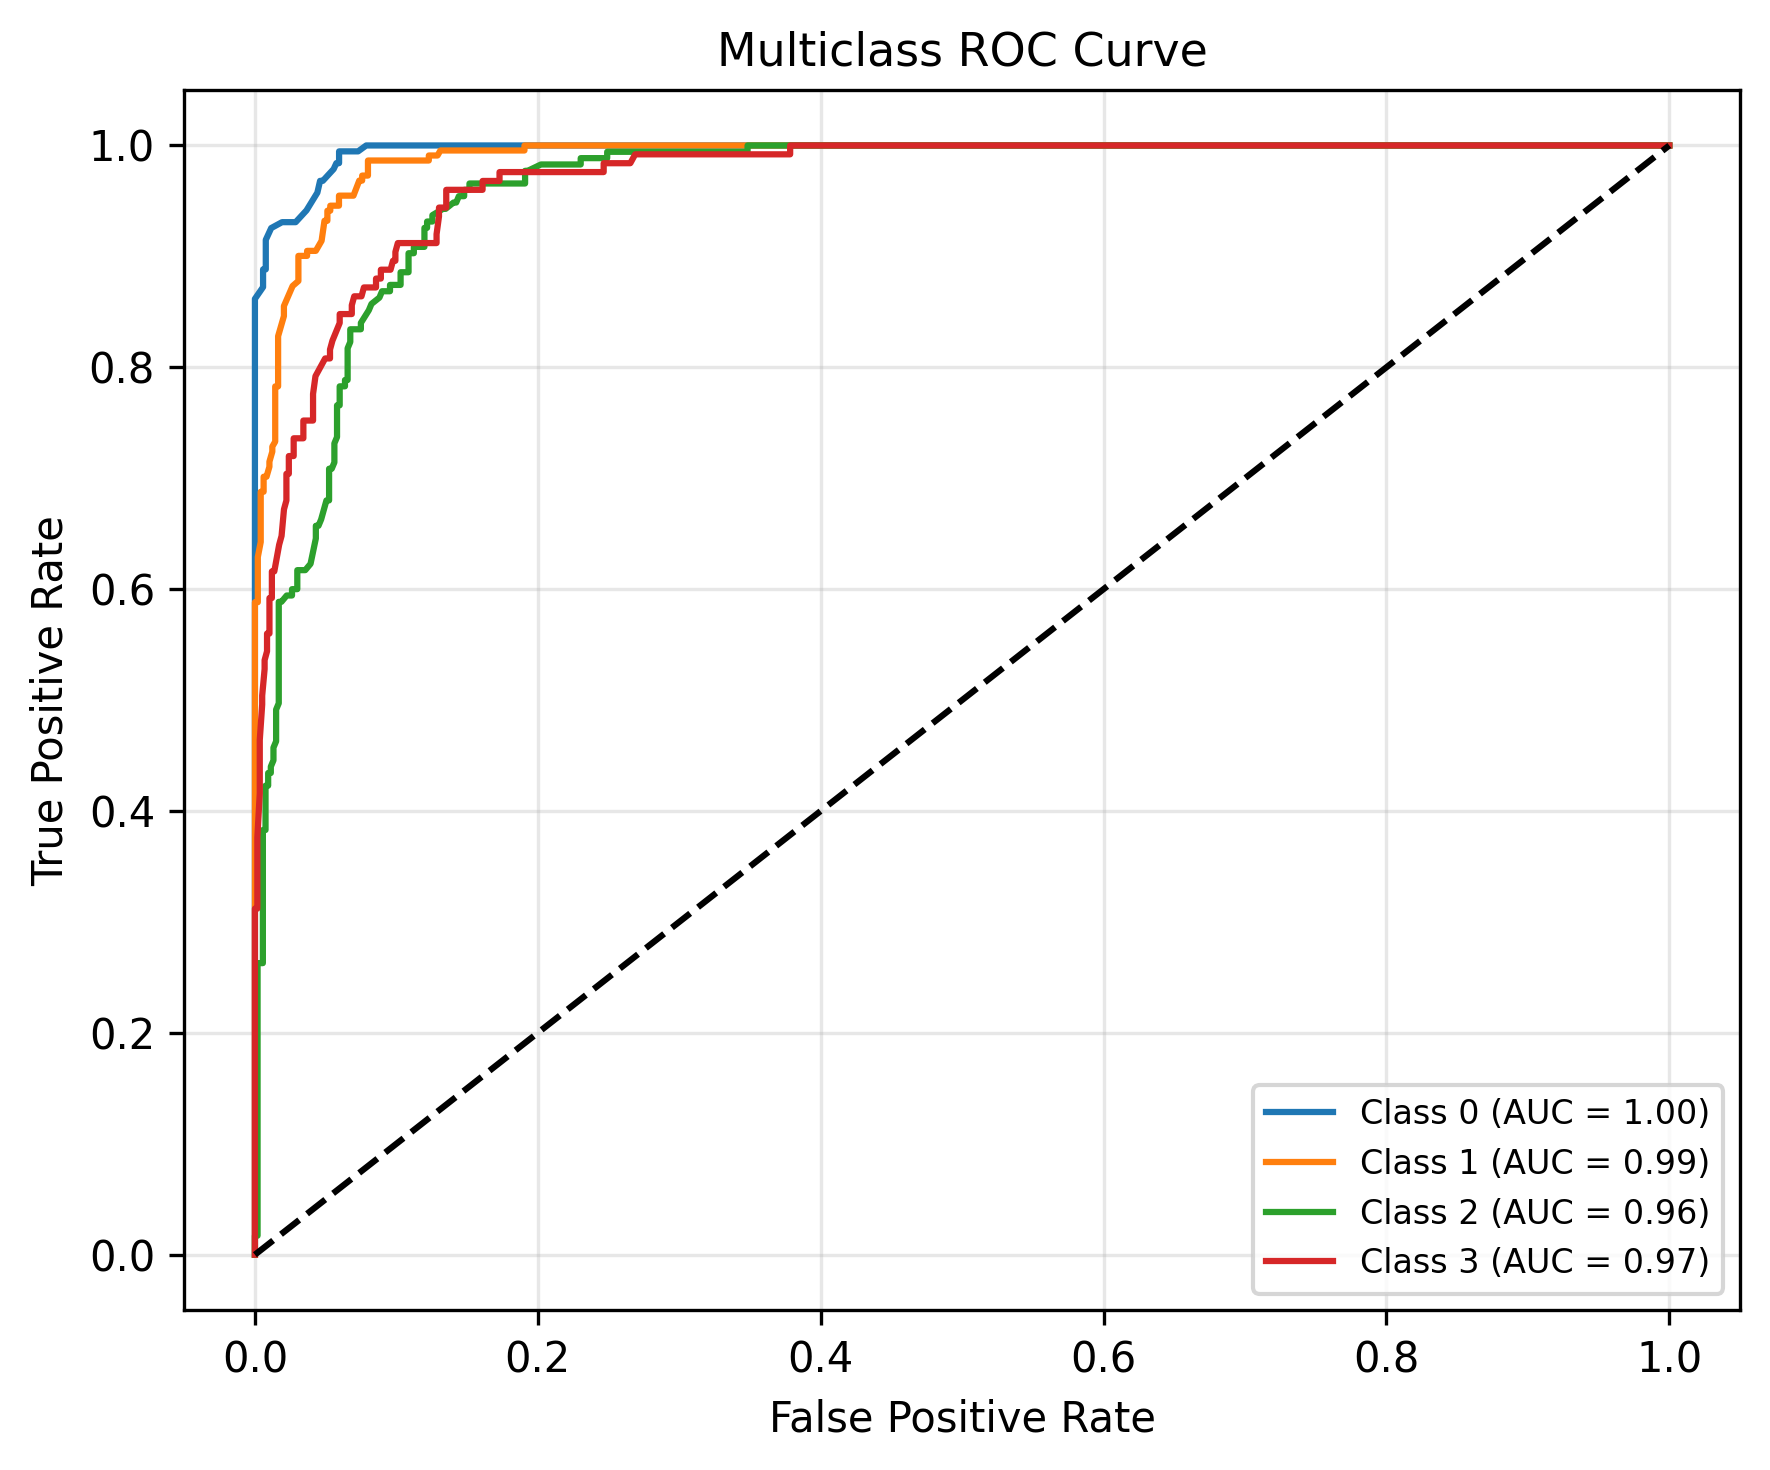

In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels
y_bin = label_binarize(y_test, classes=[0,1,2,3])

# Convert spike output to probabilities (IMPORTANT)
scores = torch.softmax(test_spk.sum(0), dim=1).detach().cpu().numpy()

n_classes = y_bin.shape[1]

plt.figure(figsize=(6,5), dpi=300)

# Plot ROC for each class
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

# Diagonal line
plt.plot([0,1], [0,1], 'k--')


plt.xlabel("False Positive Rate", fontsize=10)
plt.ylabel("True Positive Rate", fontsize=10)
plt.title("Multiclass ROC Curve", fontsize=11)

plt.legend(fontsize=8)
plt.grid(alpha=0.3)

plt.tight_layout()



In [23]:
plt.figure(figsize=(6,5), dpi=300)

plt.plot(train_loss_list, label="Train Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curve.pdf")

plt.show()

NameError: name 'train_loss_list' is not defined

<Figure size 1800x1500 with 0 Axes>

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, predicted, average=None)
recall = recall_score(y_test, predicted, average=None)
f1 = f1_score(y_test, predicted, average=None)

labels = ["Normal", "Soap", "Mud", "Blockage"]

for i in range(4):
    print(labels[i])
    print("Precision:", precision[i])
    print("Recall:", recall[i])
    print("F1:", f1[i])
    print()

Normal
Precision: 0.9358288770053476
Recall: 0.9308510638297872
F1: 0.9333333333333333

Soap
Precision: 0.8942731277533039
Recall: 0.918552036199095
F1: 0.90625

Mud
Precision: 0.8
Recall: 0.8
F1: 0.8

Blockage
Precision: 0.7916666666666666
Recall: 0.76
F1: 0.7755102040816326



### Export Weights From our Trained Model

In [19]:
import numpy as np

w1 = model.fc1.weight.detach().cpu().numpy()
b1 = model.fc1.bias.detach().cpu().numpy()

w2 = model.fc2.weight.detach().cpu().numpy()
b2 = model.fc2.bias.detach().cpu().numpy()

np.save("fc1_w.npy", w1)
np.save("fc1_b.npy", b1)
np.save("fc2_w.npy", w2)
np.save("fc2_b.npy", b2)

print("Weights exported")

Weights exported


### Convert Weights → Arduino Arrays

In [20]:
import numpy as np

def to_c_array(name, arr):
    flat = arr.flatten()
    s = f"float {name}[] = {{"
    s += ",".join([str(float(x)) for x in flat])
    s += "};"
    return s

w1 = np.load("fc1_w.npy")
b1 = np.load("fc1_b.npy")
w2 = np.load("fc2_w.npy")
b2 = np.load("fc2_b.npy")

print(to_c_array("W1", w1))
print(to_c_array("B1", b1))
print(to_c_array("W2", w2))
print(to_c_array("B2", b2))

float W1[] = {-0.10293808579444885,-0.34550774097442627,-0.1588260382413864,-0.11746330559253693,-0.20521777868270874,-0.05413776636123657,0.0655246451497078,1.0174286365509033,0.026698194444179535,0.16640007495880127,-0.7073221802711487,-0.24704398214817047,-0.37496882677078247,0.0036331615410745144,-3.2401485443115234,-0.37657666206359863,0.5808632373809814,-2.963927984237671,-0.23301443457603455,0.14707538485527039,-1.3521573543548584,-0.08600442111492157,-1.0452589988708496,-1.750287652015686,0.15169864892959595,0.29722291231155396,-0.02127215638756752,-0.12106315791606903,-0.20965301990509033,-0.2487422376871109,-0.44380873441696167,-0.9893994331359863,-0.041098304092884064,0.04580431059002876,0.25168576836586,0.6894697546958923,1.4099483489990234,0.03958723694086075,-0.17807242274284363,-0.15264900028705597,-0.13573625683784485,-0.5044006705284119,0.13779935240745544,0.9395161867141724,0.121236152946949,-0.19558745622634888,-0.20837493240833282,-0.3458521068096161,0.0798020288348